## Polytope Climate-DT example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots. Specifically this notebook shows how to do server side interpolation to a supported grid.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
from earthkit.geo import regrid

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

Further information on the `grid` and `interpolation` keywords and their usage can be found on the following page: https://polytope.readthedocs.io/en/latest/Service/Full_fields/

In [ ]:
request = {
    "activity": "projections",
    'class': 'd1',
    'dataset': 'climate-dt',
    "date": "20400102",
    'time': "0000",
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    "generation": "2",
    'levtype': 'sfc',
    'model': 'IFS-NEMO',
    'param': '167',
    'realization': '1',
    "resolution": "standard",
    'stream': 'clte',
    'grid' : 'O128', # currently O, F, N, H, HN grids are supported 
    'interpolation' : 'bilinear',
    'type': 'fc',
}

In [ ]:
data_file = "../data/climate-dt-earthkit-grid-example.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.mn5.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
df = data.to_fieldlist()
df.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2040-01-02,2040-01-02,0 days,2,height_above_ground_level,None,reduced_gg


In [ ]:
data_latlon = regrid(
    df,
    out_grid={"grid": [0.1,0.1]},
    interpolation="linear"
)

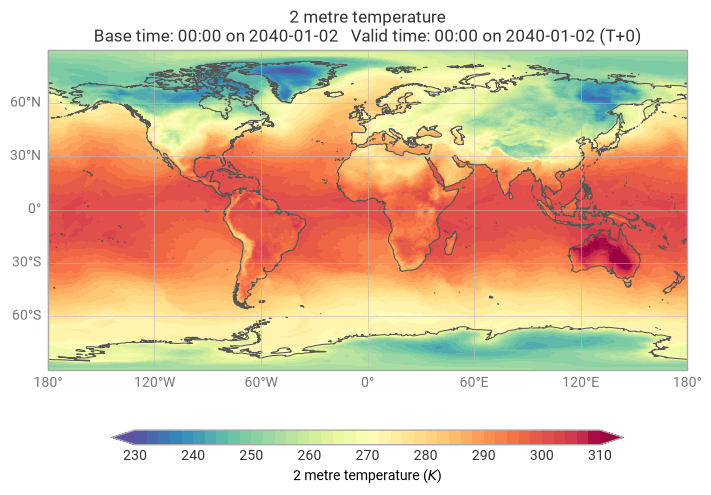

In [ ]:
chart = earthkit.plots.Map()
chart.grid_cells(data_latlon[0], style='auto')
chart.legend()
chart.gridlines()
chart.title()
chart.coastlines()
chart.show()